# Figure 5 (Standalone) - Does Increasing Width Preserve Plasticity?

**Self-contained version for Google Colab** — every function this experiment needs (environments, models, replay buffer, DQN loop, plasticity probe with baseline comparison) is defined inline below; there are no imports from the repository's `src/` package. Upload this single file to Colab and run it.

**Colab setup**: `Runtime → Change runtime type → GPU` (a T4 is plenty). All required libraries are preinstalled on Colab.

**What it reproduces**: Appendix A.2's width sweep from Lyle et al., *Understanding Plasticity in Neural Networks*. A natural hypothesis is that plasticity loss is really a capacity problem — a wide enough network wouldn't lose it. The sweep trains a DQN agent at each width and measures plasticity loss (final probe loss minus the initial checkpoint's probe loss) the same way figure 3 does. For MLPs, `width` is the hidden-layer size; for CNNs, `width` is the conv channel count with the fully connected width set to `4 * width`.

**Chunked execution**: every config is an independent run — split the paper sweep across sessions by architecture, environment, or width factor, and merge the CSVs afterwards (see the bottom sections).

## Setup

Paths are relative to the working directory (`/content` on Colab). Datasets download automatically; results land in `outputs/tables` and `outputs/figures` — download them via Colab's file browser before the session ends.

In [1]:
import copy
import random
import time
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm.auto import tqdm

ROOT = Path.cwd()
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
for directory in (DATA_ROOT, OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def _default_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():  # Apple-silicon GPU
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = _default_device()
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Using device: mps


/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environments: the Classification MDPs (paper Section 3.2)

In [2]:
@dataclass(frozen=True)
class ClassificationMDPSpec:
    name: str
    num_states: int = 10
    num_actions: int = 10


class ClassificationMDP:
    def __init__(self, dataset, spec, labels=None, seed=None):
        self.dataset = dataset
        self.spec = spec
        self.rng = random.Random(seed)
        self.labels = labels if labels is not None else self._true_labels(dataset)
        self.class_indices = self._build_class_indices(self.labels)
        self.state = self.rng.randrange(self.spec.num_states)

    @staticmethod
    def _true_labels(dataset):
        targets = getattr(dataset, "targets", None)
        if targets is None:
            return [int(dataset[idx][1]) for idx in range(len(dataset))]
        if isinstance(targets, torch.Tensor):
            return [int(value) for value in targets.tolist()]
        return [int(value) for value in targets]

    def _build_class_indices(self, labels):
        class_indices = {state: [] for state in range(self.spec.num_states)}
        for idx, raw_label in enumerate(labels):
            label = int(raw_label)
            if 0 <= label < self.spec.num_states:
                class_indices[label].append(idx)
        empty = [state for state, indices in class_indices.items() if not indices]
        if empty:
            raise ValueError(f"Every MDP state must have at least one image. Missing states: {empty}")
        return class_indices

    def reset(self, state=None):
        self.state = self.rng.randrange(self.spec.num_states) if state is None else int(state)
        return self.sample_observation(self.state)

    def sample_observation(self, state=None):
        state = self.state if state is None else int(state)
        idx = self.rng.choice(self.class_indices[state])
        image, _ = self.dataset[idx]
        return image

    def transition(self, action):
        raise NotImplementedError

    def step(self, action):
        reward, next_state = self.transition(int(action))
        self.state = int(next_state)
        return self.sample_observation(self.state), float(reward), self.state


def make_random_labels(dataset, num_states=10, seed=None):
    rng = random.Random(seed)
    return [rng.randrange(num_states) for _ in range(len(dataset))]


class EasyMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        super().__init__(dataset, ClassificationMDPSpec(name="easy"), seed=seed)

    def transition(self, action):
        reward = float(int(action) == int(self.state))
        self.state = self.rng.randrange(self.spec.num_states)
        return reward, self.state


## Models (paper Appendix A.2)

Width is the swept variable: for MLPs it's `hidden_dim`; for CNNs it's `conv_channels` (with `fc_dim = 4 * width` set by the sweep helper below).

In [3]:
def _prod(values):
    out = 1
    for v in values:
        out *= int(v)
    return out


def _maybe_spectral_norm(module, enabled):
    return nn.utils.spectral_norm(module) if enabled else module


class MLP(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), num_actions=10, hidden_dim=512,
                 use_layernorm=False, spectral_norm=False):
        super().__init__()
        self.input_dim = _prod(input_shape)
        self.hidden_dim = int(hidden_dim)
        self.num_actions = int(num_actions)
        self.feature_dim = self.hidden_dim

        self.fc1 = _maybe_spectral_norm(nn.Linear(self.input_dim, self.hidden_dim), spectral_norm)
        self.fc2 = _maybe_spectral_norm(nn.Linear(self.hidden_dim, self.hidden_dim), spectral_norm)
        self.output = nn.Linear(self.hidden_dim, self.num_actions)

        self.ln1 = nn.LayerNorm(self.hidden_dim) if use_layernorm else nn.Identity()
        self.ln2 = nn.LayerNorm(self.hidden_dim) if use_layernorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    def forward_features(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu1(self.ln1(self.fc1(x)))
        x = self.relu2(self.ln2(self.fc2(x)))
        return x

    def forward(self, x):
        return self.output(self.forward_features(x))


class CNN(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), num_actions=10, conv_channels=64,
                 fc_dim=256, use_layernorm=False, spectral_norm=False):
        super().__init__()
        input_channels = int(input_shape[0])
        self.input_shape = tuple(int(v) for v in input_shape)
        self.num_actions = int(num_actions)
        self.conv_channels = int(conv_channels)
        self.fc_dim = int(fc_dim)
        self.feature_dim = self.fc_dim

        self.conv1 = _maybe_spectral_norm(nn.Conv2d(input_channels, self.conv_channels, kernel_size=5), spectral_norm)
        self.conv2 = _maybe_spectral_norm(nn.Conv2d(self.conv_channels, self.conv_channels, kernel_size=3), spectral_norm)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.flatten = nn.Flatten()

        with torch.no_grad():
            dummy = torch.zeros(1, *self.input_shape)
            conv1_shape = self.conv1(dummy).shape[1:]
            conv2_shape = self.conv2(self.relu1(self.conv1(dummy))).shape[1:]
            conv_dim = int(torch.numel(torch.zeros(conv2_shape)))

        self.ln1 = nn.LayerNorm(conv1_shape) if use_layernorm else nn.Identity()
        self.ln2 = nn.LayerNorm(conv2_shape) if use_layernorm else nn.Identity()

        self.fc1 = _maybe_spectral_norm(nn.Linear(conv_dim, self.fc_dim), spectral_norm)
        self.fc2 = _maybe_spectral_norm(nn.Linear(self.fc_dim, self.fc_dim), spectral_norm)
        self.output = nn.Linear(self.fc_dim, self.num_actions)

        self.ln3 = nn.LayerNorm(self.fc_dim) if use_layernorm else nn.Identity()
        self.ln4 = nn.LayerNorm(self.fc_dim) if use_layernorm else nn.Identity()
        self.relu3 = nn.ReLU()
        self.relu4 = nn.ReLU()

    def forward_features(self, x):
        x = self.relu1(self.ln1(self.conv1(x)))
        x = self.relu2(self.ln2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.ln3(self.fc1(x)))
        x = self.relu4(self.ln4(self.fc2(x)))
        return x

    def forward(self, x):
        return self.output(self.forward_features(x))

## Replay Buffer

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        from collections import deque
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
        self.device = DEVICE

    def push(self, image, action, reward, next_image):
        self.buffer.append((image, action, reward, next_image))

    def sample(self, batch_size, device=None):
        device = self.device if device is None else device
        batch = random.sample(self.buffer, batch_size)
        images, actions, rewards, next_images = zip(*batch)
        return (
            torch.tensor(np.array(images), dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_images), dtype=torch.float32, device=device),
        )

    def sample_states(self, batch_size, device=None):
        device = self.device if device is None else device
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        images = [item[0] for item in batch]
        return torch.tensor(np.array(images), dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.buffer)

## DQN Training Loop

`run_dqn_training` trains end-to-end and also returns a clone of the network **at initialization** (`initial_model`) — the baseline this experiment measures plasticity loss against. (The repository version also supports checkpoints, periodic interventions and metric callbacks used by other figures; trimmed here.)

In [5]:
@dataclass
class ClassificationDQNConfig:
    seed: int = 0
    data_root: str = "./data"
    download: bool = True
    observation_space: str = "mnist"
    environment: str = "easy"
    architecture: str = "mlp"
    hidden_dim: int = 512
    cnn_channels: int = 64
    cnn_fc_dim: int = 256
    gamma: float = 0.99
    lr: float = 1e-3
    optimizer: str = "adam"
    weight_decay: float = 0.0
    batch_size: int = 512
    replay_capacity: int = 10_000
    warmup_steps: int = 2_000
    train_steps: int = 20_000
    target_update_period: int = 1_000
    epsilon_start: float = 1.0
    epsilon_final: float = 0.1
    epsilon_decay: int = 10_000
    use_layernorm: bool = False
    spectral_norm: bool = False


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_dataset(config):
    if config.observation_space == "mnist":
        dataset = datasets.MNIST(root=str(config.data_root), train=True,
                                 download=config.download, transform=transforms.ToTensor())
        input_shape = (1, 28, 28)
    elif config.observation_space == "cifar10":
        dataset = datasets.CIFAR10(root=str(config.data_root), train=True,
                                   download=config.download, transform=transforms.ToTensor())
        input_shape = (3, 32, 32)
    else:
        raise ValueError(f"Unknown observation space: {config.observation_space}")
    return dataset, input_shape


def build_environment(config, dataset):
    if config.environment == "easy":
        return EasyMDP(dataset, seed=config.seed)
    raise ValueError(f"Unknown environment: {config.environment}")


def build_model_factory(config, input_shape):
    def factory():
        if config.architecture == "mlp":
            return MLP(input_shape=input_shape, num_actions=10, hidden_dim=config.hidden_dim,
                       use_layernorm=config.use_layernorm, spectral_norm=config.spectral_norm)
        if config.architecture == "cnn":
            return CNN(input_shape=input_shape, num_actions=10, conv_channels=config.cnn_channels,
                       fc_dim=config.cnn_fc_dim, use_layernorm=config.use_layernorm,
                       spectral_norm=config.spectral_norm)
        raise ValueError(f"Unknown architecture: {config.architecture}")
    return factory


def build_optimizer(config, model):
    if config.optimizer == "adam":
        return torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    raise ValueError(f"Unknown optimizer: {config.optimizer}")


def optimizer_factory_from_config(config):
    def factory(model):
        return build_optimizer(config, model)
    return factory


def epsilon_at_step(config, step):
    return config.epsilon_final + (config.epsilon_start - config.epsilon_final) * np.exp(
        -float(step) / float(config.epsilon_decay)
    )


@torch.no_grad()
def select_action(model, observation, epsilon, device=None):
    device = DEVICE if device is None else device
    if random.random() < epsilon:
        return random.randrange(10)
    q_values = model(observation.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(env, model, replay, epsilon, device=None):
    observation = env.sample_observation()
    action = select_action(model, observation, epsilon, device=device)
    next_observation, reward, _ = env.step(action)
    replay.push(observation, action, reward, next_observation)


def dqn_loss(model, target_model, batch, gamma):
    states, actions, rewards, next_states = batch
    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        target = rewards + gamma * next_q
    return F.mse_loss(q_sa, target)


def train_dqn_step(model, target_model, optimizer, replay, config, device=None):
    device = DEVICE if device is None else device
    batch = replay.sample(config.batch_size, device=device)
    loss = dqn_loss(model, target_model, batch, config.gamma)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return float(loss.detach().cpu().item())


def run_dqn_training(config, device=None):
    device = DEVICE if device is None else device
    set_seed(config.seed)
    dataset, input_shape = load_dataset(config)
    env = build_environment(config, dataset)
    model_factory = build_model_factory(config, input_shape)
    model = model_factory().to(device)
    initial_model = copy.deepcopy(model).to(device)
    initial_model.eval()
    target_model = copy.deepcopy(model).to(device)
    optimizer = build_optimizer(config, model)
    replay = ReplayBuffer(config.replay_capacity)

    for _ in tqdm(range(config.warmup_steps), desc="warmup", unit="step", leave=False):
        collect_transition(env, model, replay, epsilon=1.0, device=device)

    last_loss = float("nan")
    train_bar = tqdm(range(1, config.train_steps + 1), desc="train", unit="step")
    for step in train_bar:
        epsilon = epsilon_at_step(config, step)
        collect_transition(env, model, replay, epsilon=epsilon, device=device)
        last_loss = train_dqn_step(model, target_model, optimizer, replay, config, device=device)

        if step % 100 == 0:
            train_bar.set_postfix(loss=f"{last_loss:.4f}", eps=f"{epsilon:.2f}")

        if step % config.target_update_period == 0:
            target_model.load_state_dict(model.state_dict())
    train_bar.close()

    return {
        "config": config,
        "model": model,
        "initial_model": initial_model,
        "model_factory": model_factory,
        "replay": replay,
        "last_loss": last_loss,
    }

## Plasticity Probe with Baseline Comparison (paper Sections 2.2 / 3.1)

`measure_plasticity_loss` runs the random-target probe on the trained model AND on the initial-checkpoint baseline; plasticity loss is the difference of their mean final probe losses.

In [6]:
@dataclass
class PlasticityProbeConfig:
    steps: int = 2000
    num_tasks: int = 10
    batch_size: Optional[int] = None
    target_scale: float = 1e5
    log_every: Optional[int] = None


@dataclass
class ProbeTaskResult:
    initial_loss: float
    final_loss: float
    learning_curve: List[Dict[str, float]]


@dataclass
class PlasticityResult:
    probe_loss: float
    baseline_probe_loss: Optional[float]
    plasticity_loss: Optional[float]
    task_losses: List[float]
    baseline_task_losses: Optional[List[float]]


def _device_of(model):
    return next(model.parameters()).device


def _sample_indices(inputs, batch_size):
    if batch_size is None or batch_size >= inputs.size(0):
        return None
    return torch.randint(0, inputs.size(0), (batch_size,), device=inputs.device)


@torch.no_grad()
def make_random_function_targets(model, random_model, inputs, target_scale=1e5):
    model.eval()
    random_model.eval()
    inputs = inputs.to(_device_of(model))
    random_model = random_model.to(inputs.device)
    offset = model(inputs).mean(dim=0, keepdim=True)
    random_outputs = random_model(inputs)
    return (offset + torch.sin(target_scale * random_outputs)).detach()


def train_probe_task(model, inputs, targets, optimizer_factory, config, progress_desc=None):
    probe_model = copy.deepcopy(model).to(_device_of(model))
    inputs = inputs.to(_device_of(probe_model))
    targets = targets.to(_device_of(probe_model))
    optimizer = optimizer_factory(probe_model)

    with torch.no_grad():
        initial_loss = float(F.mse_loss(probe_model(inputs), targets).cpu().item())

    probe_model.train()
    step_iter = tqdm(range(1, config.steps + 1), desc=progress_desc, unit="step",
                     leave=False, disable=progress_desc is None)
    for step in step_iter:
        indices = _sample_indices(inputs, config.batch_size)
        if indices is None:
            batch_inputs, batch_targets = inputs, targets
        else:
            batch_inputs = inputs.index_select(0, indices)
            batch_targets = targets.index_select(0, indices)

        loss = F.mse_loss(probe_model(batch_inputs), batch_targets)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if progress_desc is not None and step % 50 == 0:
            step_iter.set_postfix(loss=f"{float(loss.detach().cpu()):.4f}")

    with torch.no_grad():
        final_loss = float(F.mse_loss(probe_model(inputs), targets).cpu().item())

    return ProbeTaskResult(initial_loss=initial_loss, final_loss=final_loss, learning_curve=[])


def run_random_probe_task(model, random_model_factory, inputs, optimizer_factory, config, progress_desc=None):
    random_model = random_model_factory().to(_device_of(model))
    targets = make_random_function_targets(model, random_model, inputs, target_scale=config.target_scale)
    return train_probe_task(model, inputs, targets, optimizer_factory, config, progress_desc=progress_desc)


def estimate_probe_loss(model, random_model_factory, inputs, optimizer_factory, config, desc=None):
    return [
        run_random_probe_task(
            model, random_model_factory, inputs, optimizer_factory, config,
            progress_desc=None if desc is None else f"{desc} [task {task + 1}/{config.num_tasks}]",
        )
        for task in range(config.num_tasks)
    ]


def measure_plasticity_loss(model, random_model_factory, inputs, optimizer_factory, config,
                            baseline_model=None, desc=None):
    task_results = estimate_probe_loss(
        model, random_model_factory, inputs, optimizer_factory, config,
        desc=None if desc is None else f"{desc} (trained)",
    )
    task_losses = [result.final_loss for result in task_results]
    probe_loss = float(np.mean(task_losses))

    baseline_task_losses = None
    baseline_probe_loss = None
    if baseline_model is not None:
        baseline_results = estimate_probe_loss(
            baseline_model, random_model_factory, inputs, optimizer_factory, config,
            desc=None if desc is None else f"{desc} (initial)",
        )
        baseline_task_losses = [result.final_loss for result in baseline_results]
        baseline_probe_loss = float(np.mean(baseline_task_losses))

    plasticity_loss = None if baseline_probe_loss is None else float(probe_loss - baseline_probe_loss)

    return PlasticityResult(
        probe_loss=probe_loss,
        baseline_probe_loss=baseline_probe_loss,
        plasticity_loss=plasticity_loss,
        task_losses=task_losses,
        baseline_task_losses=baseline_task_losses,
    )

## Figure 5 Experiment: Config, Width Mapping, and Sweep Runner

`config_for_width` maps a single `width` value onto the right architecture-specific fields (`hidden_dim` for MLPs; `cnn_channels`/`cnn_fc_dim = 4*width` for CNNs). Each width config trains once and measures plasticity loss against its own initial checkpoint.

In [7]:
@dataclass
class WidthSweepConfig(ClassificationDQNConfig):
    width: int = 512
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 512


def config_for_width(base, architecture, width):
    if architecture == "mlp":
        return replace(base, architecture="mlp", width=int(width), hidden_dim=int(width))
    if architecture == "cnn":
        return replace(base, architecture="cnn", width=int(width),
                       cnn_channels=int(width), cnn_fc_dim=int(4 * width))
    raise ValueError(f"Unsupported width-sweep architecture: {architecture}")


def run_id_for(config):
    return (f"{config.observation_space}_{config.environment}_"
            f"{config.architecture}_w{config.width}_seed{config.seed}")


def run_width_config(config):
    training = run_dqn_training(config, device=DEVICE)
    replay = training["replay"]
    inputs = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps, num_tasks=config.num_probe_tasks, batch_size=config.probe_batch_size,
    )
    result = measure_plasticity_loss(
        training["model"], training["model_factory"], inputs,
        optimizer_factory_from_config(config), probe_config,
        baseline_model=training["initial_model"], desc="probe",
    )
    row = {
        "seed": config.seed,
        "observation_space": config.observation_space,
        "environment": config.environment,
        "architecture": config.architecture,
        "width": config.width,
        "hidden_dim": config.hidden_dim,
        "cnn_channels": config.cnn_channels,
        "cnn_fc_dim": config.cnn_fc_dim,
        "probe_loss": result.probe_loss,
        "initial_probe_loss": result.baseline_probe_loss,
        "plasticity_loss": result.plasticity_loss,
    }
    print(f"    probe_loss={row['probe_loss']:.4f} initial={row['initial_probe_loss']:.4f} "
          f"plasticity_loss={row['plasticity_loss']:+.4f}")
    return row


def run_width_sweep(configs, save_path=None):
    rows = []
    sweep_start = time.perf_counter()
    for idx, config in enumerate(configs, start=1):
        print(f"[{idx}/{len(configs)}] {run_id_for(config)}")
        config_start = time.perf_counter()
        rows.append(run_width_config(config))
        config_min = (time.perf_counter() - config_start) / 60
        elapsed_min = (time.perf_counter() - sweep_start) / 60
        remaining_min = elapsed_min / idx * (len(configs) - idx)
        print(f"[{idx}/{len(configs)}] done in {config_min:.1f} min | "
              f"elapsed {elapsed_min:.1f} min | est. remaining {remaining_min:.0f} min")
    df = pd.DataFrame(rows)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved width sweep table to {save_path}")
    return df

## Config Factories

`make_smoke_configs` runs 4 tiny width/architecture combinations. `make_width_sweep_configs` reproduces the paper's sweep: widths at `base_width * factor` for `factor in (1, 2, 4, 8, 12, 16)`, across both architectures and all three environments (36 configs at the defaults).

In [29]:
def make_width_sweep_configs(data_root="./data", download=True,
                             architectures=("mlp", "cnn"),
                             observation_space=("mnist", "cifar10"),
                             base_width=16, factors=(1, 2, 4, 8, 12, 16)):
    base = WidthSweepConfig(
        data_root=data_root, download=download, observation_space=observation_space,
        batch_size=512, replay_capacity=10_000, warmup_steps=2_000, train_steps=20_000,
        target_update_period=1_000, probe_steps=2_000, num_probe_tasks=10, probe_batch_size=512,
    )
    configs = []
    for architecture in architectures:
        for factor in factors:
            for obs_space in observation_space:
                base = replace(base, observation_space=obs_space)
                configs.append(config_for_width(base, architecture, base_width * factor))
    return configs


def make_smoke_configs(data_root="./data", download=True):
    base = WidthSweepConfig(
        data_root=data_root, download=download,
        observation_space="mnist", environment="easy",
        batch_size=128, replay_capacity=5_000, warmup_steps=512, train_steps=1_000,
        target_update_period=250, probe_steps=50, num_probe_tasks=2, probe_batch_size=128,
    )
    return [
        config_for_width(base, "mlp", 32),
        config_for_width(base, "mlp", 64),
        config_for_width(base, "cnn", 16),
        config_for_width(base, "cnn", 32),
    ]

## Smoke Run (fast sanity check)

In [9]:
smoke_df = run_width_sweep(make_smoke_configs(data_root=str(DATA_ROOT)),
                           save_path=TABLES_DIR / "figure5_smoke.csv")
smoke_df

[1/4] mnist_easy_mlp_w32_seed0


train: 100%|██████████| 1000/1000 [00:04<00:00, 246.29step/s, eps=0.91, loss=0.0676]


    probe_loss=0.3091 initial=0.2728 plasticity_loss=+0.0363
[1/4] done in 0.1 min | elapsed 0.1 min | est. remaining 0 min
[2/4] mnist_easy_mlp_w64_seed0


train: 100%|██████████| 1000/1000 [00:02<00:00, 345.82step/s, eps=0.91, loss=0.0373]


    probe_loss=0.2539 initial=0.1197 plasticity_loss=+0.1342
[2/4] done in 0.1 min | elapsed 0.1 min | est. remaining 0 min
[3/4] mnist_easy_cnn_w16_seed0


train: 100%|██████████| 1000/1000 [00:10<00:00, 92.48step/s, eps=0.91, loss=0.0095]


    probe_loss=0.1779 initial=0.1027 plasticity_loss=+0.0752
[3/4] done in 0.2 min | elapsed 0.3 min | est. remaining 0 min
[4/4] mnist_easy_cnn_w32_seed0


train: 100%|██████████| 1000/1000 [00:17<00:00, 55.89step/s, eps=0.91, loss=0.0019]


    probe_loss=0.0455 initial=0.0146 plasticity_loss=+0.0310
[4/4] done in 0.3 min | elapsed 0.6 min | est. remaining 0 min
Saved width sweep table to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/notebooks/outputs/tables/figure5_smoke.csv


,seed,observation_space,environment,architecture,width,hidden_dim,cnn_channels,cnn_fc_dim,probe_loss,initial_probe_loss,plasticity_loss
0,0,mnist,easy,mlp,32,32,64,256,0.309105,0.272811,0.036294
1,0,mnist,easy,mlp,64,64,64,256,0.253906,0.119708,0.134198
2,0,mnist,easy,cnn,16,512,16,64,0.177891,0.102738,0.075152
3,0,mnist,easy,cnn,32,512,32,128,0.045542,0.014592,0.030950


## Chunked Paper-Scale Run

Every config is independent — split the 36-config sweep across sessions along any axis and merge the CSVs afterwards. Edit the filter for this session's slice and **give each chunk a distinct `save_path`**. Rough per-config cost on a Colab T4: small-width MLPs a few minutes; the widest CNN configs (256 channels, fc 1024) are the heavy end — give them their own chunk.

In [33]:
all_configs = make_width_sweep_configs(data_root=str(DATA_ROOT))
print(f"total paper configs: {len(all_configs)}")

# EDIT THIS FILTER for the current session's chunk, e.g.:
#   chunk = [c for c in all_configs if c.architecture == "mlp"]
#   chunk = [c for c in all_configs if c.architecture == "cnn" and c.environment == "easy"]
#   chunk = [c for c in all_configs if c.width <= 64]
chunk = [c for c in all_configs if c.architecture == "cnn"]
chunk_name = "cnn"  # EDIT: used in the output filename

print(f"this session runs {len(chunk)} configs: {[run_id_for(c) for c in chunk]}")

# Uncomment to launch:
chunk_df = run_width_sweep(chunk, save_path=TABLES_DIR / f"figure5_chunk_{chunk_name}.csv")

total paper configs: 24
this session runs 12 configs: ['mnist_easy_cnn_w16_seed0', 'cifar10_easy_cnn_w16_seed0', 'mnist_easy_cnn_w32_seed0', 'cifar10_easy_cnn_w32_seed0', 'mnist_easy_cnn_w64_seed0', 'cifar10_easy_cnn_w64_seed0', 'mnist_easy_cnn_w128_seed0', 'cifar10_easy_cnn_w128_seed0', 'mnist_easy_cnn_w192_seed0', 'cifar10_easy_cnn_w192_seed0', 'mnist_easy_cnn_w256_seed0', 'cifar10_easy_cnn_w256_seed0']
[1/12] mnist_easy_cnn_w16_seed0


train:   4%|▍         | 891/20000 [00:17<06:06, 52.14step/s, eps=0.93, loss=0.0008]


KeyboardInterrupt: 

## Merging Chunks + Plot

Collect all `figure5_chunk_*.csv` files into `outputs/tables/` on one machine, then run the cells below (falls back to the smoke results if no chunks are present).

In [20]:
import glob

chunk_paths = sorted(glob.glob(str(TABLES_DIR / "figure5_chunk_*.csv")))
if chunk_paths:
    width_df = pd.concat([pd.read_csv(p) for p in chunk_paths], ignore_index=True)
    print(f"merged {len(chunk_paths)} chunks -> {len(width_df)} rows")
else:
    width_df = smoke_df
    print("no chunk files found; using smoke results")

merged 1 chunks -> 6 rows


Saved width sweep figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/notebooks/outputs/figures/figure5_width_sweep.png


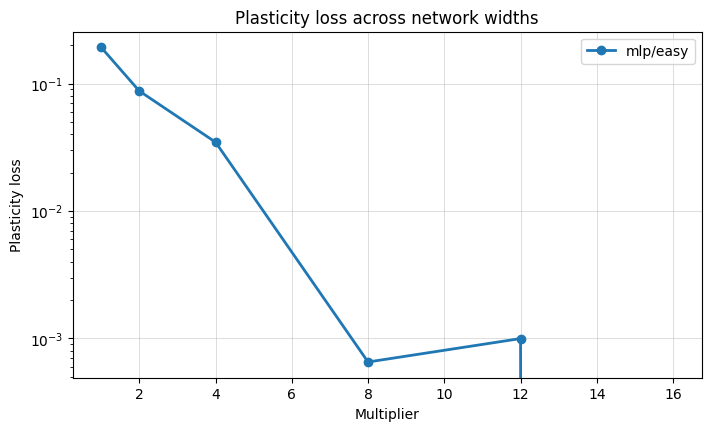

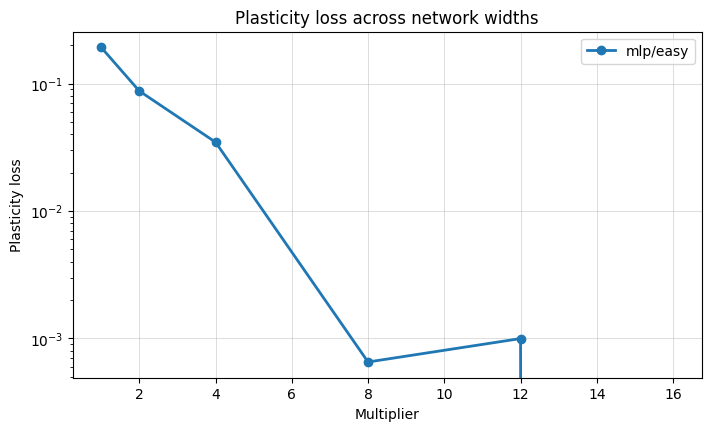

In [24]:
def plot_width_sweep(df, save_path=None):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
    for (architecture, environment), group in df.groupby(["architecture", "environment"]):
        group = group.sort_values("width")
        ax.plot(group["width"] / group["width"].min(), group["plasticity_loss"], marker="o", linewidth=2.0,
                label=f"{architecture}/{environment}")

    ax.set_xlabel("Multiplier")
    ax.set_ylabel("Plasticity loss")
    ax.set_yscale("log")
    ax.set_title("Plasticity loss across network widths")
    ax.grid(True, linewidth=0.6, alpha=0.5)
    ax.legend()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved width sweep figure to {save_path}")
    return fig


fig = plot_width_sweep(width_df, save_path=FIGURES_DIR / "figure5_width_sweep.png")
fig